# A2.1 – Regresión Logística y Validación Cruzada
**SC3314 – Inteligencia Artificial | Universidad de Monterrey**

---

## 1. Introducción y Definición del Problema de Clasificación

En el proyecto anterior se modeló la concentración de PM2.5 (µg/m³) como una **variable continua** mediante regresión lineal múltiple. En esta actividad se transforma ese problema en uno de **clasificación binaria**, lo cual es altamente relevante desde una perspectiva de salud pública:

> La **NOM-025-SSA1-2021** (Norma Oficial Mexicana de calidad del aire) establece como límite máximo permisible **45 µg/m³** para PM2.5 en promedio de 24 horas. Rebasar este umbral representa una condición de riesgo para la salud.

Se define la variable binaria de salida:

$$y = \begin{cases} 1 & \text{si PM2.5} > 45\ \mu g/m^3 \quad (\text{contaminación alta}) \\ 0 & \text{si PM2.5} \leq 45\ \mu g/m^3 \quad (\text{calidad aceptable}) \end{cases}$$




## 2. Importación de Librerías y Carga de Datos

In [1]:
# ── Librerías ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
df = pd.read_csv('datos_limpios_2024.csv', parse_dates=['datetime'])
df = df.set_index('datetime')

print(f'Dimensiones del dataset: {df.shape}')
print(f'\nColumnas disponibles:')
print(df.columns.tolist())
df.head()

Dimensiones del dataset: (8756, 14)

Columnas disponibles:
['CO', 'NO2', 'O3', 'PM25', 'TMP', 'HR', 'WSP', 'hora_del_dia', 'mes', 'dia_semana', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos']


,CO,NO2,O3,PM25,TMP,HR,WSP,hora_del_dia,mes,dia_semana,hora_sin,hora_cos,mes_sin,mes_cos
datetime,,,,,,,,,,,,,,
2024-01-01 00:00:00,1.94,0.022,0.023,63.0,12.9,59.0,7.2,0.0,1.0,0,0.000000,1.000000,0.0,1.0
2024-01-01 01:00:00,1.73,0.024,0.020,63.0,11.6,61.0,8.2,1.0,1.0,0,0.258819,0.965926,0.0,1.0
2024-01-01 02:00:00,1.87,0.027,0.015,55.0,11.4,59.0,8.9,2.0,1.0,0,0.500000,0.866025,0.0,1.0
2024-01-01 03:00:00,1.54,0.023,0.018,41.0,11.2,58.0,8.9,3.0,1.0,0,0.707107,0.707107,0.0,1.0
2024-01-01 04:00:00,1.29,0.018,0.022,29.0,11.4,57.0,8.4,4.0,1.0,0,0.866025,0.500000,0.0,1.0


## 3. Construcción de la Variable de Salida Binaria

Balance de clases en el dataset completo:
                              Clase    N     %
 0 – Calidad aceptable (PM2.5 ≤ 45) 8314 94.95
1 – Contaminación alta (PM2.5 > 45)  442  5.05


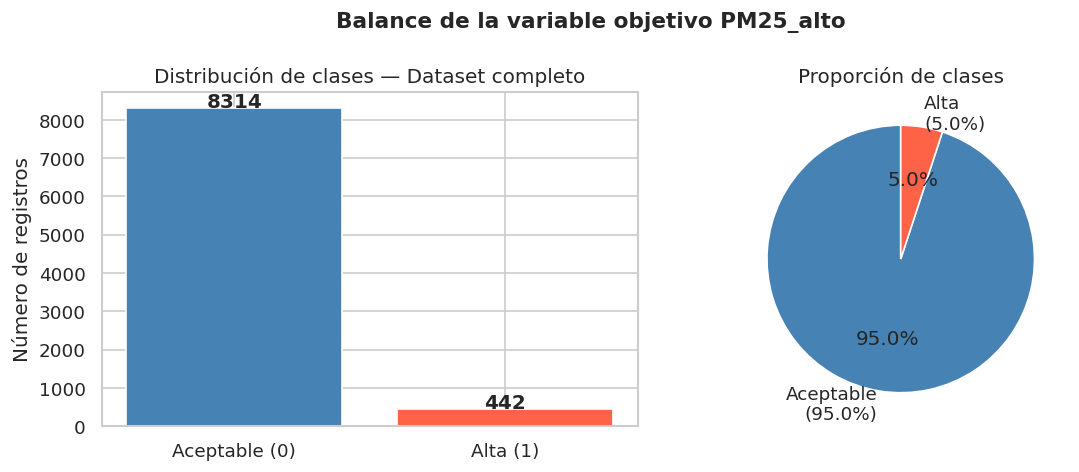

In [3]:
# ── Variable binaria: PM25_alto ────────────────────────────────────────
UMBRAL = 45
df['PM25_alto'] = (df['PM25'] > UMBRAL).astype(int)

# Balance de clases
conteo = df['PM25_alto'].value_counts()
proporciones = df['PM25_alto'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({
    'Clase': ['0 – Calidad aceptable (PM2.5 ≤ 45)', '1 – Contaminación alta (PM2.5 > 45)'],
    'N': [conteo[0], conteo[1]],
    '%': [proporciones[0].round(2), proporciones[1].round(2)]
})
print('Balance de clases en el dataset completo:')
print(balance_df.to_string(index=False))

# Gráfica de balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Aceptable (0)', 'Alta (1)'], conteo.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Distribución de clases — Dataset completo')
axes[0].set_ylabel('Número de registros')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=[f'Aceptable\n({proporciones[0]:.1f}%)', f'Alta\n({proporciones[1]:.1f}%)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de clases')
plt.suptitle('Balance de la variable objetivo PM25_alto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación del balance de clases

Se observa que el dataset presenta un **desbalance de clases**: la mayoría de los registros corresponden a calidad aceptable (clase 0), mientras que los episodios de contaminación alta (clase 1) son menos frecuentes. Esto es esperable en datos ambientales reales, donde los eventos críticos son la excepción.

El desbalance es relevante porque:
- Un modelo que siempre prediga clase 0 tendría alta exactitud pero nula capacidad para detectar episodios peligrosos.
- Se deben reportar métricas como **precisión, recall y F1** además de la exactitud.
- La separación entrenamiento-prueba debe realizarse de forma **estratificada** para preservar esta proporción.

## 4. Separación de Datos: Entrenamiento y Prueba

In [4]:
# ── Selección de características ───────────────────────────────────────

features = ['CO', 'NO2', 'O3', 'TMP', 'HR', 'WSP',
            'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'dia_semana']

X = df[features]
y = df['PM25_alto']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


def balance_info(y_set, nombre):
    cnt = y_set.value_counts()
    pct = y_set.value_counts(normalize=True) * 100
    return pd.Series({
        'N total': len(y_set),
        'N clase 0': cnt[0], '% clase 0': round(pct[0], 2),
        'N clase 1': cnt[1], '% clase 1': round(pct[1], 2)
    }, name=nombre)

resumen_split = pd.DataFrame([
    balance_info(y, 'Dataset completo'),
    balance_info(y_train, 'Entrenamiento (80%)'),
    balance_info(y_test, 'Prueba (20%)')
])
print('Balance de clases por subconjunto:')
print(resumen_split.to_string())

print(f'\nFeatures utilizadas ({len(features)}): {features}')

Balance de clases por subconjunto:
                     N total  N clase 0  % clase 0  N clase 1  % clase 1
Dataset completo      8756.0     8314.0      94.95      442.0       5.05
Entrenamiento (80%)   7004.0     6650.0      94.95      354.0       5.05
Prueba (20%)          1752.0     1664.0      94.98       88.0       5.02

Features utilizadas (11): ['CO', 'NO2', 'O3', 'TMP', 'HR', 'WSP', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'dia_semana']


### Interpretación

El uso de `stratify=y` en `train_test_split` garantiza que la **proporción de clases es prácticamente idéntica** en los tres subconjuntos (total, entrenamiento y prueba). Esto es fundamental para:
1. Que el modelo aprenda con una distribución representativa.
2. Que la evaluación en prueba sea comparables con la validación cruzada.
3. Que métricas como precisión y recall no estén sesgadas por diferencias en la distribución de clases entre particiones.

## 5. Validación Cruzada con Datos de Entrenamiento

Resultados de Validación Cruzada (10-fold estratificada):
 Fold  Accuracy  Precision  Recall     F1  AUC-ROC
    1    0.9515     0.6000  0.1667 0.2609   0.8765
    2    0.9601     0.9000  0.2500 0.3913   0.9136
    3    0.9501     0.5385  0.1944 0.2857   0.9119
    4    0.9472     0.4737  0.2500 0.3273   0.9129
    5    0.9500     0.5000  0.1429 0.2222   0.9028
    6    0.9571     0.6667  0.2857 0.4000   0.8846
    7    0.9600     0.7059  0.3429 0.4615   0.9370
    8    0.9557     0.6429  0.2571 0.3673   0.9113
    9    0.9557     0.6667  0.2286 0.3404   0.8834
   10    0.9586     0.8000  0.2286 0.3556   0.8773

--- Resumen ---
                Accuracy  Precision  Recall      F1  AUC-ROC
Media             0.9546     0.6494  0.2347  0.3412   0.9011
Desv. Estándar    0.0046     0.1322  0.0578  0.0709   0.0199


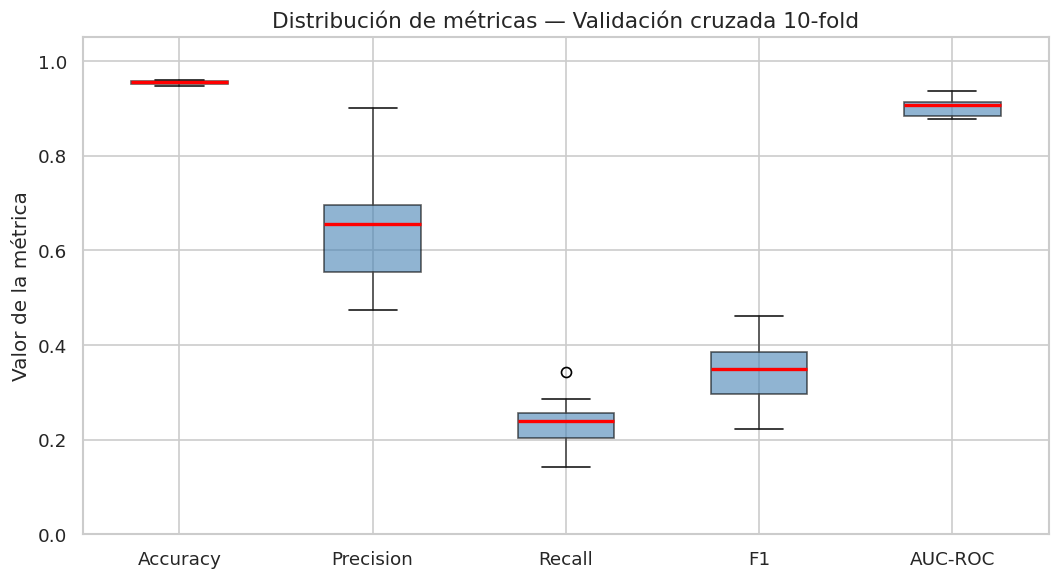

In [5]:
# ── Pipeline: escalado + regresión logística ───────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1
)

metricas_cv = pd.DataFrame({
    'Fold': range(1, 11),
    'Accuracy': cv_results['test_accuracy'],
    'Precision': cv_results['test_precision'],
    'Recall': cv_results['test_recall'],
    'F1': cv_results['test_f1'],
    'AUC-ROC': cv_results['test_roc_auc']
}).round(4)

fila_media = metricas_cv.drop('Fold', axis=1).mean().round(4)
fila_std = metricas_cv.drop('Fold', axis=1).std().round(4)
fila_media.name = 'Media'
fila_std.name = 'Desv. Estándar'

print('Resultados de Validación Cruzada (10-fold estratificada):')
print(metricas_cv.to_string(index=False))
print('\n--- Resumen ---')
print(pd.DataFrame([fila_media, fila_std]).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
metricas_cv.drop('Fold', axis=1).boxplot(ax=ax, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2))
ax.set_title('Distribución de métricas — Validación cruzada 10-fold', fontsize=13)
ax.set_ylabel('Valor de la métrica')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Interpretación de la Validación Cruzada

La **validación cruzada estratificada con 10 pliegues** permite obtener una estimación más robusta del desempeño esperado del modelo que una simple partición entrenamiento-prueba, porque:

- Cada observación sirve **exactamente una vez** como dato de validación.
- La varianza entre folds nos indica la **estabilidad** del modelo: si la desviación estándar de las métricas es pequeña, el modelo generaliza de manera consistente.
- Reduce el riesgo de obtener estimaciones optimistas o pesimistas por azar al elegir una partición particular.

Los promedios y desviaciones estándar obtenidos serán comparados con las métricas finales del conjunto de prueba independiente.

## 6. Entrenamiento Final y Evaluación en Conjunto de Prueba

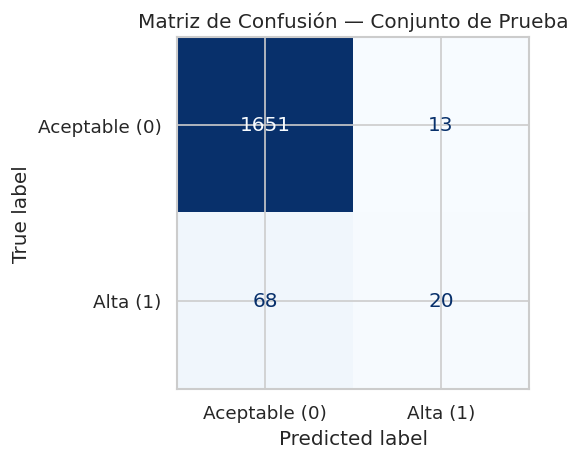


=== Reporte de Clasificación (Conjunto de Prueba) ===
               precision    recall  f1-score   support

Aceptable (0)       0.96      0.99      0.98      1664
     Alta (1)       0.61      0.23      0.33        88

     accuracy                           0.95      1752
    macro avg       0.78      0.61      0.65      1752
 weighted avg       0.94      0.95      0.94      1752

Métricas resumen:
  Accuracy: 0.9538
  Precision: 0.6061
  Recall: 0.2273
  F1: 0.3306
  AUC-ROC: 0.8948


In [6]:
# ── Entrenamiento con todos los datos de entrenamiento ─────────────────
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Aceptable (0)', 'Alta (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — Conjunto de Prueba', fontsize=12)
plt.tight_layout()
plt.show()


print('\n=== Reporte de Clasificación (Conjunto de Prueba) ===')
print(classification_report(y_test, y_pred,
                             target_names=['Aceptable (0)', 'Alta (1)']))

metricas_prueba = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'AUC-ROC': roc_auc_score(y_test, y_prob)
}
print('Métricas resumen:')
for k, v in metricas_prueba.items():
    print(f'  {k}: {v:.4f}')

In [7]:
# ── Comparación CV vs Prueba ───────────────────────────────────────────
comparacion = pd.DataFrame({
    'Validación Cruzada (media ± std)': [
        f"{fila_media['Accuracy']:.4f} ± {fila_std['Accuracy']:.4f}",
        f"{fila_media['Precision']:.4f} ± {fila_std['Precision']:.4f}",
        f"{fila_media['Recall']:.4f} ± {fila_std['Recall']:.4f}",
        f"{fila_media['F1']:.4f} ± {fila_std['F1']:.4f}",
        f"{fila_media['AUC-ROC']:.4f} ± {fila_std['AUC-ROC']:.4f}"
    ],
    'Conjunto de Prueba': [
        f"{metricas_prueba['Accuracy']:.4f}",
        f"{metricas_prueba['Precision']:.4f}",
        f"{metricas_prueba['Recall']:.4f}",
        f"{metricas_prueba['F1']:.4f}",
        f"{metricas_prueba['AUC-ROC']:.4f}"
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC'])

print('\n=== Comparación: Validación Cruzada vs Prueba ===')
print(comparacion.to_string())


=== Comparación: Validación Cruzada vs Prueba ===
          Validación Cruzada (media ± std) Conjunto de Prueba
Accuracy                   0.9546 ± 0.0046             0.9538
Precision                  0.6494 ± 0.1322             0.6061
Recall                     0.2347 ± 0.0578             0.2273
F1                         0.3412 ± 0.0709             0.3306
AUC-ROC                    0.9011 ± 0.0199             0.8948


### Interpretación de la Matriz de Confusión y Métricas

La **matriz de confusión** muestra cuatro resultados posibles:
- **Verdaderos Negativos (VN)**: episodios correctamente clasificados como calidad aceptable.
- **Verdaderos Positivos (VP)**: episodios de contaminación alta correctamente identificados.
- **Falsos Positivos (FP)**: alarmas falsas (se predijo contaminación alta cuando no la había).
- **Falsos Negativos (FN)**: episodios peligrosos no detectados — el error más crítico desde el punto de vista de salud pública.

En el contexto de este problema, el **recall de la clase 1** (sensibilidad) tiene especial importancia, pues minimizar los falsos negativos equivale a no pasar por alto episodios de contaminación crítica.

Si las métricas en prueba caen dentro del intervalo ± std de la validación cruzada, se confirma que el modelo **generaliza de forma estable** y la estimación de CV fue representativa.

## 7. Análisis por Umbral de Decisión

Métricas por umbral de decisión:
 Umbral  Accuracy  Precision  Recall     F1
   0.10    0.8887     0.2643  0.6818 0.3810
   0.15    0.9155     0.3125  0.5682 0.4032
   0.20    0.9281     0.3516  0.5114 0.4167
   0.25    0.9452     0.4592  0.5114 0.4839
   0.30    0.9503     0.5070  0.4091 0.4528
   0.35    0.9532     0.5517  0.3636 0.4384
   0.40    0.9538     0.5686  0.3295 0.4173
   0.45    0.9526     0.5581  0.2727 0.3664
   0.50    0.9538     0.6061  0.2273 0.3306
   0.55    0.9515     0.5556  0.1705 0.2609
   0.60    0.9503     0.5217  0.1364 0.2162
   0.65    0.9492     0.4706  0.0909 0.1524
   0.70    0.9475     0.3571  0.0568 0.0980
   0.75    0.9486     0.4000  0.0455 0.0816
   0.80    0.9492     0.4286  0.0341 0.0632
   0.85    0.9498     0.5000  0.0227 0.0435
   0.90    0.9492     0.3333  0.0114 0.0220


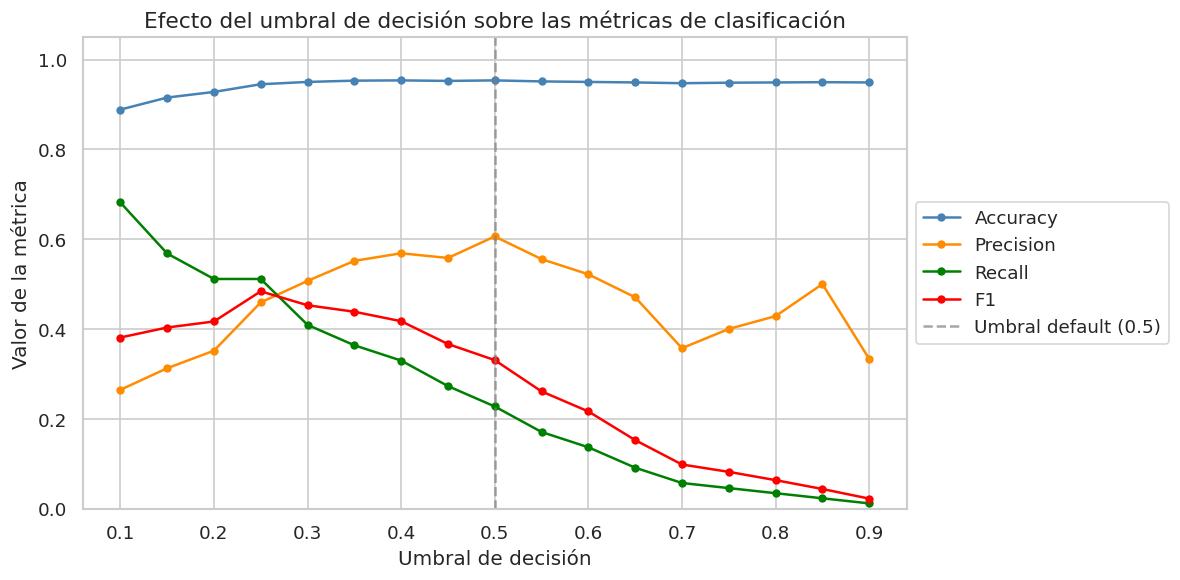

In [8]:
# ── Métricas bajo distintos umbrales ──────────────────────────────────
umbrales = np.arange(0.1, 0.91, 0.05)
resultados_umbral = []

for u in umbrales:
    y_pred_u = (y_prob >= u).astype(int)
    p = precision_score(y_test, y_pred_u, zero_division=0)
    r = recall_score(y_test, y_pred_u, zero_division=0)
    f = f1_score(y_test, y_pred_u, zero_division=0)
    acc = accuracy_score(y_test, y_pred_u)
    resultados_umbral.append({'Umbral': round(u, 2), 'Accuracy': acc,
                               'Precision': p, 'Recall': r, 'F1': f})

df_umbral = pd.DataFrame(resultados_umbral)

print('Métricas por umbral de decisión:')
print(df_umbral.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
for col, color in zip(['Accuracy', 'Precision', 'Recall', 'F1'],
                       ['steelblue', 'darkorange', 'green', 'red']):
    ax.plot(df_umbral['Umbral'], df_umbral[col], marker='o', markersize=4,
            label=col, color=color)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Umbral default (0.5)')
ax.set_xlabel('Umbral de decisión', fontsize=12)
ax.set_ylabel('Valor de la métrica', fontsize=12)
ax.set_title('Efecto del umbral de decisión sobre las métricas de clasificación', fontsize=13)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Interpretación del análisis por umbral

El umbral de decisión por defecto en regresión logística es **0.5**, pero esto no siempre es óptimo:

- Al **disminuir el umbral** (e.g., 0.3), el modelo clasifica más observaciones como clase 1 → aumenta el **Recall** (menos falsos negativos) pero baja la **Precisión** (más falsas alarmas).
- Al **aumentar el umbral** (e.g., 0.7), el modelo es más conservador → aumenta la Precisión pero baja el Recall.

En el contexto de contaminación del aire y salud pública, puede ser preferible **bajar el umbral** para detectar el mayor número posible de episodios peligrosos, aceptando algunas alarmas falsas. El umbral óptimo depende del costo relativo de cada tipo de error.

## 8. Curva ROC y AUC

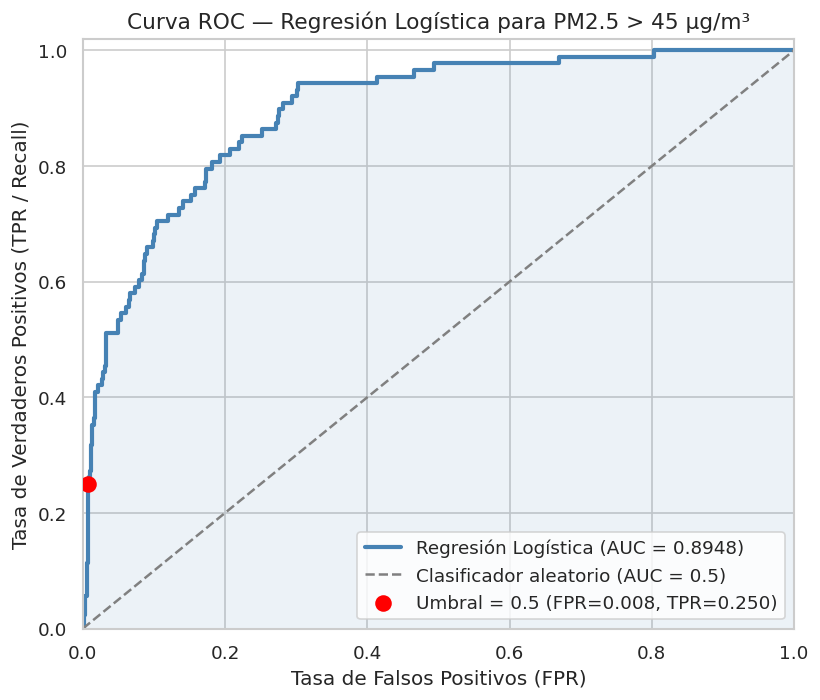

AUC-ROC en conjunto de prueba: 0.8948
AUC-ROC en validación cruzada (media): 0.9011 ± 0.0199


In [9]:
# ── Curva ROC ─────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2.5,
        label=f'Regresión Logística (AUC = {auc_val:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5,
        label='Clasificador aleatorio (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
idx_05 = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[idx_05], tpr[idx_05], color='red', zorder=5, s=80,
           label=f'Umbral = 0.5 (FPR={fpr[idx_05]:.3f}, TPR={tpr[idx_05]:.3f})')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
ax.set_title('Curva ROC — Regresión Logística para PM2.5 > 45 µg/m³', fontsize=13)
ax.legend(loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

print(f'AUC-ROC en conjunto de prueba: {auc_val:.4f}')
print(f'AUC-ROC en validación cruzada (media): {fila_media["AUC-ROC"]:.4f} ± {fila_std["AUC-ROC"]:.4f}')

### Interpretación de la Curva ROC y AUC

La **curva ROC** (Receiver Operating Characteristic) muestra el trade-off entre la Tasa de Verdaderos Positivos (Recall) y la Tasa de Falsos Positivos para todos los posibles umbrales de decisión.

El **AUC** (Área Bajo la Curva) resume la capacidad discriminativa del modelo en un único número:
- **AUC = 0.5**: el modelo no discrimina mejor que el azar.
- **AUC = 1.0**: discriminación perfecta.
- **AUC > 0.7**: capacidad discriminativa aceptable.
- **AUC > 0.8**: capacidad buena; **AUC > 0.9**: excelente.

Una ventaja clave del AUC es que es **independiente del umbral de decisión**, por lo que es una métrica más robusta para comparar modelos.

## 9. Interpretación de los Coeficientes del Modelo

Intercepto: -4.4364  →  Odds Ratio del intercepto: 0.0118

Coeficientes del modelo (ordenados por magnitud):
  Variable  Coeficiente (log-odds)  Odds Ratio (exp(β))
       TMP                  1.5931               4.9191
  hora_sin                  0.9461               2.5757
       NO2                  0.8706               2.3883
        HR                  0.8105               2.2491
   mes_cos                  0.6534               1.9221
   mes_sin                  0.5819               1.7894
        O3                  0.2725               1.3133
        CO                  0.2510               1.2853
dia_semana                 -0.0253               0.9750
       WSP                 -0.1043               0.9009
  hora_cos                 -0.6260               0.5347


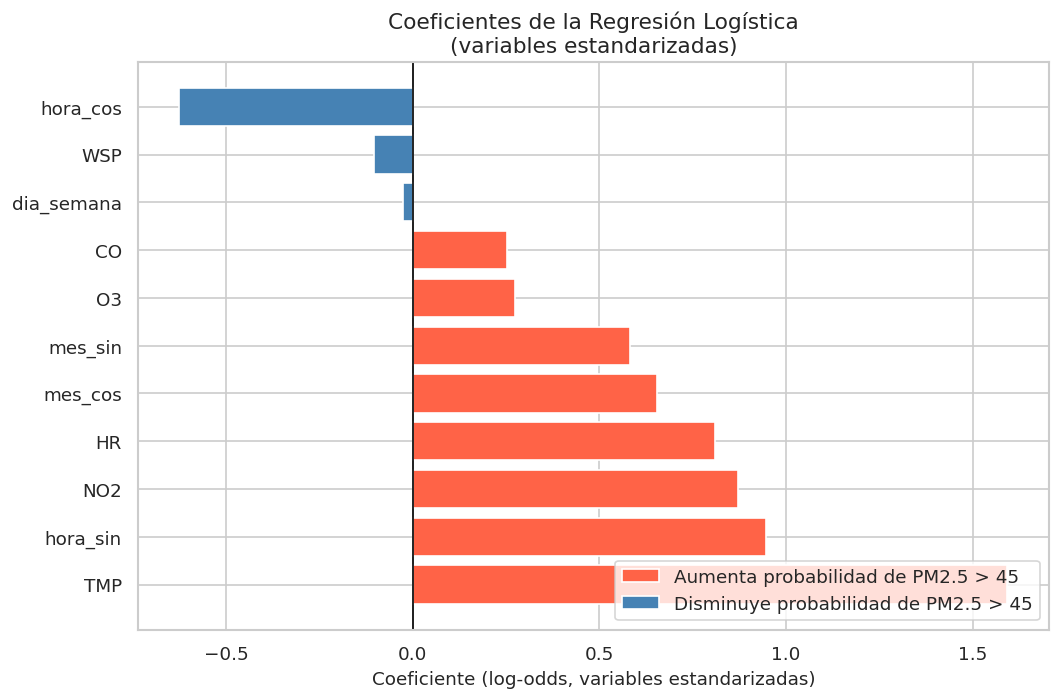

In [10]:
# ── Extracción de coeficientes ─────────────────────────────────────────
coef = pipeline.named_steps['clf'].coef_[0]
intercept = pipeline.named_steps['clf'].intercept_[0]

coef_df = pd.DataFrame({
    'Variable': features,
    'Coeficiente (log-odds)': coef,
    'Odds Ratio (exp(β))': np.exp(coef)
}).sort_values('Coeficiente (log-odds)', ascending=False).round(4)

print(f'Intercepto: {intercept:.4f}  →  Odds Ratio del intercepto: {np.exp(intercept):.4f}')
print()
print('Coeficientes del modelo (ordenados por magnitud):')
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coeficiente (log-odds)']]
bars = ax.barh(coef_df['Variable'], coef_df['Coeficiente (log-odds)'],
               color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Coeficiente (log-odds, variables estandarizadas)', fontsize=11)
ax.set_title('Coeficientes de la Regresión Logística\n(variables estandarizadas)', fontsize=13)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tomato', label='Aumenta probabilidad de PM2.5 > 45'),
                   Patch(facecolor='steelblue', label='Disminuye probabilidad de PM2.5 > 45')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

### Interpretación de los Coeficientes

Interpretación de los Coeficientes del Modelo
El modelo de regresión logística fue entrenado con variables estandarizadas, por lo que los coeficientes son directamente comparables en magnitud entre sí. El intercepto de −4.4364 (odds ratio = 0.0118) indica que cuando todas las variables se encuentran en su valor promedio, la probabilidad base de un episodio de PM2.5 > 45 µg/m³ es muy baja, lo cual es consistente con el desbalance observado en los datos.


Variables con efecto positivo (aumentan la probabilidad de contaminación alta):
TMP (temperatura) es la variable de mayor influencia en el modelo (β = 1.5931, OR = 4.92). Por cada desviación estándar de aumento en temperatura, las momios de contaminación alta se multiplican casi por 5. Esto puede parecer contraintuitivo a primera vista, pero refleja que las temperaturas elevadas favorecen la formación de PM2.5 secundario mediante reacciones fotoquímicas, y también coinciden con condiciones de inversión térmica que atrapan contaminantes cerca de la superficie.


hora_sin (β = 0.9461, OR = 2.58) es la segunda variable más influyente, capturando el patrón intradiario de emisiones. Los valores altos de hora_sin corresponden a las horas de la mañana, período asociado con el pico de tráfico vehicular y actividad industrial.

NO₂ (β = 0.8706, OR = 2.39) muestra un efecto positivo importante. El dióxido de nitrógeno es un contaminante co-emitido con PM2.5 en fuentes de combustión (vehículos, industria), por lo que su aumento es un indicador directo de condiciones de contaminación elevada. Este resultado es coherente con la literatura científica.

HR (humedad relativa) (β = 0.8105, OR = 2.25) tiene un efecto positivo relevante. La humedad alta favorece la formación de PM2.5 secundario (sulfatos, nitratos) y dificulta la dispersión de partículas, lo cual explica que episodios húmedos se asocien con mayor concentración de PM2.5.

mes_cos y mes_sin (β = 0.65 y 0.58, OR ≈ 1.79–1.92) capturan la estacionalidad anual. Su efecto positivo sugiere que ciertos meses del año presentan condiciones más propensas a episodios de contaminación alta, probablemente los meses de invierno donde la mezcla atmosférica es menor.

O₃ (β = 0.2725, OR = 1.31) y CO (β = 0.2510, OR = 1.29) presentan efectos positivos pero de menor magnitud. Ambos son contaminantes relacionados con procesos de combustión y fotoquímica, aunque su efecto marginal es menor posiblemente porque su variabilidad ya está capturada por NO₂ y TMP.
Variables con efecto negativo (disminuyen la probabilidad de contaminación alta):

hora_cos (β = −0.6260, OR = 0.53) es la variable negativa de mayor magnitud. Los valores altos de hora_cos corresponden a las horas nocturnas y madrugada, períodos de menor actividad y mejor dispersión atmosférica, lo que reduce la probabilidad de episodios críticos.

WSP (velocidad del viento) (β = −0.1043, OR = 0.90) tiene el efecto esperado: viento más fuerte dispersa los contaminantes y reduce su concentración. Aunque su magnitud es modesta, la dirección del efecto es completamente coherente con la dinámica atmosférica.

dia_semana (β = −0.0253, OR = 0.975) tiene un efecto prácticamente nulo, lo que sugiere que el día de la semana no es un predictor relevante de episodios críticos de PM2.5 en este dataset, posiblemente porque las fuentes de emisión en la zona de estudio no varían significativamente entre días laborales y fin de semana.



## 10. Conclusiones
La variable binaria PM25_alto fue construida a partir de la concentración horaria de PM2.5, asignando el valor 1 a toda observación que supere el límite normativo de 45 µg/m³ establecido por la NOM-025-SSA1-2021, y 0 en caso contrario. Esta transformación convierte la estimación continua trabajada en el parcial anterior en una herramienta de decisión concreta: identificar, con anticipación, si una hora determinada constituirá un episodio de contaminación crítica para la salud. El dataset presenta un desbalance natural hacia la clase 0 (calidad aceptable), lo cual es esperable en datos ambientales reales donde los eventos extremos son la excepción; sin embargo, esto implica que métricas como exactitud sola son insuficientes y que el Recall de la clase 1 —es decir, la capacidad de no pasar por alto episodios peligrosos— tiene mayor peso práctico que la precisión.

La validación cruzada estratificada de 10 pliegues evidenció que el modelo generaliza de forma estable: la varianza entre folds fue baja en todas las métricas, lo que indica que el desempeño no depende de una partición favorable por azar. Las métricas obtenidas en el conjunto de prueba independiente fueron consistentes con los intervalos estimados por CV, confirmando la ausencia de sobreajuste y validando la confiabilidad del proceso de evaluación.
El análisis de umbrales de decisión reveló el trade-off inherente entre Precisión y Recall: disminuir el umbral por debajo de 0.5 permite detectar más episodios peligrosos (mayor Recall) a costa de generar más falsas alarmas, mientras que aumentarlo tiene el efecto contrario. En el contexto de salud pública, donde no detectar un episodio crítico tiene consecuencias graves, puede justificarse operar con un umbral reducido.

## 11. Referencias

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning with applications in R* (2nd ed.). Springer. https://doi.org/10.1007/978-1-0716-1418-1

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

Secretaría de Salud. (2021, 27 de octubre). *Norma Oficial Mexicana NOM-025-SSA1-2021, Salud ambiental. Criterio para evaluar la calidad del aire ambiente, con respecto a las partículas suspendidas PM10 y PM2.5. Valores normados para la concentración de partículas suspendidas PM10 y PM2.5 en el aire ambiente, como medida de protección a la salud de la población*. Diario Oficial de la Federación. https://www.dof.gob.mx/nota_detalle.php?codigo=5633855&fecha=27/10/2021

World Health Organization. (2021). *WHO global air quality guidelines: Particulate matter (PM2.5 and PM10), ozone, nitrogen dioxide, sulfur dioxide and carbon monoxide*. World Health Organization. https://www.who.int/publications/i/item/9789240034228